© 2025 Mobile Perception Systems Lab at TU/e. All rights reserved. Licensed under the MIT License.

# Setup

In [ ]:
#collegare colab al drive con dentro validation sets di cityscapes e i due checkpoint dei modelli su COCO e Cityscape
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive/validation_Cityscapes"

eomt_cityscapes.bin  gtFine_trainvaltest.zip
eomt_coco.bin	     leftImg8bit_trainvaltest.zip


In [ ]:
#Clonare la repository GitHub con il codice
!git clone https://github.com/GiammaBigFishEngineer/MaskArchitectureAnomaly_CourseProject.git

#entrare dentro la cartella "eomt" della repository
%cd MaskArchitectureAnomaly_CourseProject/eomt

Cloning into 'MaskArchitectureAnomaly_CourseProject'...
remote: Enumerating objects: 164, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 164 (delta 31), reused 18 (delta 18), pack-reused 79 (from 3)
Receiving objects: 100% (164/164), 28.21 MiB | 20.78 MiB/s, done.
Resolving deltas: 100% (39/39), done.
/content/MaskArchitectureAnomaly_CourseProject/eomt


In [ ]:
# Add the repository folders to Python's import path.
import sys # Allows importing from the 'eomt' folder
sys.path.append('/content/MaskArchitectureAnomaly_CourseProject')
sys.path.append('/content/MaskArchitectureAnomaly_CourseProject/eomt')

In [ ]:
#Install the Python dependencies required by the EoMT repository.
!python3 -m pip install -r requirements.txt

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.4/219.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 37.2 MB/s

In [ ]:
import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import RepositoryNotFoundError
import warnings
import importlib

seed_everything(0, verbose=False)

device = 0  # TODO: change to the GPU you want to use --> 0 vuol dire "la prima disponibile"
IGNORE_INDEX=255 #serve dopo per ignorare i pixel con clase 255 (ovvero che avevano una classe in COCO che non c'è in cityscapes)
img_idx = 10  # TODO: change to the index of the image you want to visualize
#config_path = "configs/dinov2/coco/panoptic/eomt_giant_1280.yaml"  # TODO: change to the config file
data_path = "/content/drive/MyDrive/validation_Cityscapes"  # TODO: change to the dataset directory

#configurazioni per EoMT trainato su Cityscape
with open("configs/dinov2/cityscapes/semantic/eomt_base_640.yaml", "r") as f:
    config_cs = yaml.safe_load(f)

#configurazioni per EoMT trainato su COCO
with open("configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml", "r") as f:
    config_coco = yaml.safe_load(f)

#with open(config_path, "r") as f:
    #config = yaml.safe_load(f)

#crea color mapping per la visualizzazione
def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping


def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

## Load dataset

Ensure the dataset files are correctly prepared and placed in the folder specified by `data_path`.

In [ ]:
data_module_name, class_name = config_cs["data"]["class_path"].rsplit(".", 1)
data_module = getattr(importlib.import_module(data_module_name), class_name)
data_module_kwargs = config_cs["data"].get("init_args", {}) #Get additional dataset parameters from the config file.

data = data_module(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_module_kwargs
)
data.setup()

# Cityscapes

## Load model Cityscapes

In [ ]:
# Select which pretrained EoMT model we want to use.
use_coco = False # Metto True per il modello COCO, False per quello Cityscapes

# Scegliamo il config e il file dei pesi in base alla scelta sopra
if use_coco:
    current_config = config_coco
    state_dict_path = "/content/drive/MyDrive/validation_Cityscapes/eomt_coco.bin"
    target_img_size = (640, 640)
    num_classes_to_load = 133 # tells the model how many classes it should output (COCO ne ha 133)
else:
    current_config = config_cs
    state_dict_path = "/content/drive/MyDrive/validation_Cityscapes/eomt_cityscapes.bin"
    num_classes_to_load = data.num_classes # Usa le classi di Cityscape (solitamente 19)
    target_img_size = data.img_size

warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
)

# Load encoder --> build encoder part of EoMT (part of the model that extracts visual features from the image. In this project, the encoder is based on DINOv2.)
encoder_cfg = current_config["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
encoder = encoder_cls(img_size=target_img_size, **encoder_cfg.get("init_args", {}))
#encoder = encoder_cls(img_size=data.img_size, **encoder_cfg.get("init_args", {}))

# Load network --> build complete EoMT network (encoder+segmentation components)
network_cfg = current_config["model"]["init_args"]["network"]
network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
network = network_cls(
    masked_attn_enabled=False,
    #num_classes=data.num_classes,
    num_classes=num_classes_to_load,
    encoder=encoder,
    **network_kwargs,
)

# Load Lightning module
lit_module_name, lit_class_name = current_config["model"]["class_path"].rsplit(".", 1)
lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
model_kwargs = {k: v for k, v in current_config["model"]["init_args"].items() if k != "network"}
if "stuff_classes" in current_config["data"].get("init_args", {}):
    model_kwargs["stuff_classes"] = current_config["data"]["init_args"]["stuff_classes"]

model = (
    lit_cls(
        img_size=target_img_size,
        #img_size=data.img_size,
        #num_classes=data.num_classes,
        num_classes=num_classes_to_load,
        network=network,
        **model_kwargs,
    )
    .eval()
    .to(device)
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

## Load pre-trained weights from Hugging Face Hub
The model weights are downloaded from the Hugging Face Hub using the logger name from the config. Make sure you have a working internet connection.

In [ ]:
#Determine the input image size expected by the selected model.
#For the COCO model, we manually force the image size to 640x640 because the selected COCO config/checkpoint was trained with this resolution.
#For the Cityscapes model, we use the image size defined by the Cityscapes data module.

if use_coco:
    target_img_size = (640, 640)
else:
    target_img_size = data.img_size

#Create a copy of the model parameters loaded from the YAML config.
#We make a copy instead of modifying model_kwargs directly, so that the original config-derived dictionary remains unchanged.
model_kwargs_final = {k: v for k, v in model_kwargs.items()}

#Remove 'num_classes' from the keyword arguments (kwargs) if it is present.
#Later, when we build the model, we explicitly pass: num_classes=num_classes_to_load
#If model_kwargs_final also contained 'num_classes', Python would receive the same argument twice and raise an error
if "num_classes" in model_kwargs_final:
  del model_kwargs_final["num_classes"]

# Get the experiment/model name from the config.
name = current_config.get("trainer", {}).get("logger", {}).get("init_args", {}).get("name")

# Check if the selected model is a DINOv3 model. In our case, the config paths are under configs/dinov2/, so this will usually be False.
is_dinov3 = "dinov3" in name if name else False
#special handling for DINOv3 models.
if is_dinov3:
    model_kwargs["ckpt_path"] = state_dict_path
    model_kwargs["delta_weights"] = True

#FINAL EoMT MODEL
model = (
    lit_cls(
        img_size=target_img_size,
        num_classes=num_classes_to_load,
        network=network,
        **model_kwargs_final,
    )
    .eval() #put the model in inference/evaluation mode
    .to(device)
)

#Load the pretrained weights from the local .bin checkpoint.
if not is_dinov3:
    state_dict = torch.load(
        state_dict_path, map_location=f"cuda:{device}", weights_only=True
    )
    model.load_state_dict(state_dict, strict=False)




## Semantic inference (pixel-wise classification)

> This inference method also works when applied to a model trained for panoptic segmentation.

Semantic inference computes per-pixel class scores by combining mask and class predictions:

$$
\sum_i p_i(c) \cdot m_i[h, w]
$$

Here, $p_i(c)$ is the class probability for class $c$ (excluding "no object"), and $m_i[h, w]$ is the sigmoid-normalized mask value for query $i$ at pixel $(h, w)$. The final class is selected by taking the argmax over classes.  
  
*This inference method was originally introduced in MaskFormer.*

In [ ]:
#Questa penso serva solo per COCO quindi possiamo spostarla sotto
coco_to_cityscapes_map = {
    0: 11,    # person -> person
    1: 18,    # bicycle -> bicycle
    2: 13,    # car -> car
    3: 17,    # motorcycle -> motorcycle
    4: 255,   # airplane -> ignore
    5: 15,    # bus -> bus
    6: 16,    # train -> train
    7: 14,    # truck -> truck
    8: 255,   # boat -> ignore
    9: 6,     # traffic light -> traffic light
    10: 255,  # fire hydrant -> ignore
    11: 7,    # stop sign -> traffic sign, approximate
    12: 255,  # parking meter -> ignore
    13: 255,  # bench -> ignore

    14: 255,  # bird -> ignore
    15: 255,  # cat -> ignore
    16: 255,  # dog -> ignore
    17: 255,  # horse -> ignore
    18: 255,  # sheep -> ignore
    19: 255,  # cow -> ignore
    20: 255,  # elephant -> ignore
    21: 255,  # bear -> ignore
    22: 255,  # zebra -> ignore
    23: 255,  # giraffe -> ignore

    24: 255,  # backpack -> ignore
    25: 255,  # umbrella -> ignore
    26: 255,  # handbag -> ignore
    27: 255,  # tie -> ignore
    28: 255,  # suitcase -> ignore

    29: 255,  # frisbee -> ignore
    30: 255,  # skis -> ignore
    31: 255,  # snowboard -> ignore
    32: 255,  # sports ball -> ignore
    33: 255,  # kite -> ignore
    34: 255,  # baseball bat -> ignore
    35: 255,  # baseball glove -> ignore
    36: 255,  # skateboard -> ignore
    37: 255,  # surfboard -> ignore
    38: 255,  # tennis racket -> ignore

    39: 255,  # bottle -> ignore
    40: 255,  # wine glass -> ignore
    41: 255,  # cup -> ignore
    42: 255,  # fork -> ignore
    43: 255,  # knife -> ignore
    44: 255,  # spoon -> ignore
    45: 255,  # bowl -> ignore

    46: 255,  # banana -> ignore
    47: 255,  # apple -> ignore
    48: 255,  # sandwich -> ignore
    49: 255,  # orange -> ignore
    50: 255,  # broccoli -> ignore
    51: 255,  # carrot -> ignore
    52: 255,  # hot dog -> ignore
    53: 255,  # pizza -> ignore
    54: 255,  # donut -> ignore
    55: 255,  # cake -> ignore

    56: 255,  # chair -> ignore
    57: 255,  # couch -> ignore
    58: 8,    # potted plant -> vegetation, approximate
    59: 255,  # bed -> ignore
    60: 255,  # dining table -> ignore
    61: 255,  # toilet -> ignore
    62: 255,  # tv -> ignore
    63: 255,  # laptop -> ignore
    64: 255,  # mouse -> ignore
    65: 255,  # remote -> ignore
    66: 255,  # keyboard -> ignore
    67: 255,  # cell phone -> ignore
    68: 255,  # microwave -> ignore
    69: 255,  # oven -> ignore
    70: 255,  # toaster -> ignore
    71: 255,  # sink -> ignore
    72: 255,  # refrigerator -> ignore
    73: 255,  # book -> ignore
    74: 255,  # clock -> ignore
    75: 255,  # vase -> ignore
    76: 255,  # scissors -> ignore
    77: 255,  # teddy bear -> ignore
    78: 255,  # hair drier -> ignore
    79: 255,  # toothbrush -> ignore
    80: 255,  # banner -> ignore
    81: 255,  # blanket -> ignore
    82: 255,  # bridge -> ignore
    83: 255,  # cardboard -> ignore
    84: 255,  # counter -> ignore
    85: 255,  # curtain -> ignore
    86: 255,  # door-stuff -> ignore
    87: 255,  # floor-wood -> ignore
    88: 8,    # flower -> vegetation, approximate
    89: 255,  # fruit -> ignore
    90: 9,    # gravel -> terrain, approximate
    91: 2,    # house -> building, approximate
    92: 255,  # light -> ignore
    93: 255,  # mirror-stuff -> ignore
    94: 255,  # net -> ignore
    95: 255,  # pillow -> ignore
    96: 255,  # platform -> ignore

    97: 255,  # playingfield -> ignore
    98: 255,  # railroad -> ignore
    99: 255,  # river -> ignore
    100: 0,   # road -> road
    101: 2,   # roof -> building, approximate
    102: 9,   # sand -> terrain, approximate
    103: 255, # sea -> ignore
    104: 255, # shelf -> ignore
    105: 255, # snow -> ignore
    106: 255, # stairs -> ignore
    107: 255, # tent -> ignore
    108: 255, # towel -> ignore
    109: 3,   # wall-brick -> wall
    110: 3,   # wall-stone -> wall
    111: 3,   # wall-tile -> wall
    112: 3,   # wall-wood -> wall
    113: 255, # water-other -> ignore
    114: 255, # window-blind -> ignore
    115: 255, # window-other -> ignore
    116: 8,   # tree-merged -> vegetation
    117: 4,   # fence-merged -> fence
    118: 255, # ceiling-merged -> ignore
    119: 10,  # sky-other-merged -> sky
    120: 255, # cabinet-merged -> ignore
    121: 255, # table-merged -> ignore
    122: 255, # floor-other-merged -> ignore
    123: 1,   # pavement-merged -> sidewalk, approximate
    124: 9,   # mountain-merged -> terrain, approximate
    125: 8,   # grass-merged -> vegetation
    126: 9,   # dirt-merged -> terrain
    127: 255, # paper-merged -> ignore
    128: 255, # food-other-merged -> ignore
    129: 2,   # building-other-merged -> building
    130: 9,   # rock-merged -> terrain
    131: 3,   # wall-other-merged -> wall
    132: 255, # rug-merged -> ignore

}

In [ ]:
# Semantic inference function.

# Input:
# - img: one image from the Cityscapes validation set
# - target: corresponding Cityscapes ground truth

# Output:
# - pred_array: predicted semantic class for each pixel
# - target_array: ground-truth semantic class for each pixe

def infer_semantic(img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model.window_imgs_semantic(imgs)  # Split the image into windows/crops for semantic inference

        #run the model on the image crops
        mask_logits_per_layer, class_logits_per_layer = model(crops)
        #mask_logits = F.interpolate( #mask_logits_per_layer[-1], data.img_size, mode="bilinear")
        mask_logits = F.interpolate(mask_logits_per_layer[-1],size=target_img_size, mode="bilinear",)

        crop_logits = model.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()

    # --- AGGIUNTA MAPPATURA ---
    # If we are using the COCO-trained model, its output labels are COCO IDs.
    # To compare them with Cityscapes ground truth, we remap them to Cityscapes IDs.
    if use_coco:
        #Start with an array filled with the ignore index.
        # Any COCO class not present in the mapping will remain ignored.
        remapped_pred = np.full(pred_array.shape, IGNORE_INDEX, dtype=np.uint8)

        # Sostituisci ogni pixel usando il tuo dizionario
        for coco_id, city_id in coco_to_cityscapes_map.items():
            remapped_pred[pred_array == coco_id] = city_id

        pred_array = remapped_pred
    # --------------------------

    target_array = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[
        0
    ].numpy()

    return pred_array, target_array

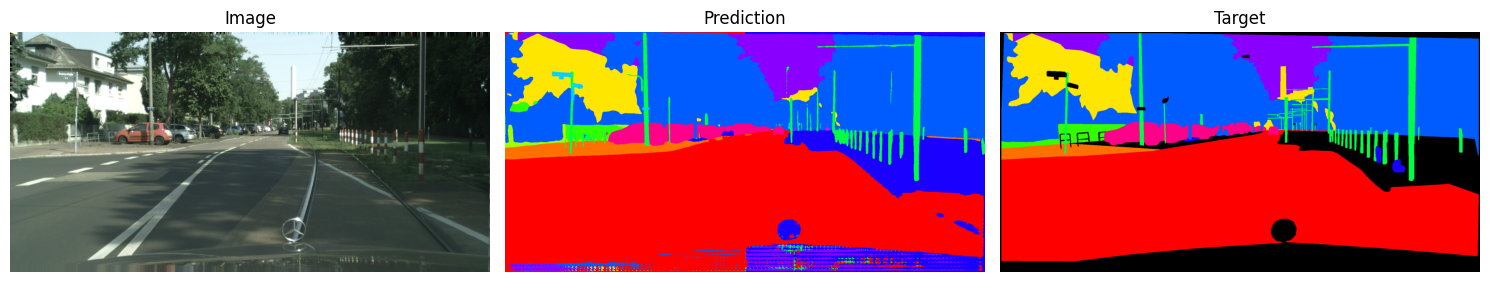

In [ ]:
def plot_semantic_results(img, pred_array, target_array):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title("Prediction")
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data.val_dataloader().dataset[img_idx]
pred_array, target_array = infer_semantic(img, target)
plot_semantic_results(img, pred_array, target_array)

In [ ]:
import torch
import numpy as np
from torchmetrics.classification import MulticlassJaccardIndex

def calculate_dataset_miou(dataset, num_classes=19, ignore_index=255):
    # Inizializziamo metrica per calcolare la mIoU media su tutte le classi.
    miou_mean_metric = MulticlassJaccardIndex(
        num_classes=num_classes,
        average="macro"
    ).to(device)

    # Inizializziamo una seconda metrica per ottenere la IoU separata
    # per ogni singola classe Cityscapes.
    miou_class_metric = MulticlassJaccardIndex(
        num_classes=num_classes,
        average=None
    ).to(device)

    print(f"Inizio calcolo mIoU su {len(dataset)} immagini...")

    for i in range(len(dataset)):
        img, target = dataset[i]

        pred_array, target_array = infer_semantic(img, target)
        pred_array = np.asarray(pred_array)
        target_array = np.asarray(target_array)

        # Keep only pixels where BOTH prediction and target are valid Cityscapes classes.
        # Valid Cityscapes trainIds are 0, ..., 18.
        # Pixels with 255 are ignored.
        valid_mask = (
            (target_array >= 0) &
            (target_array < num_classes) &
            (pred_array >= 0) &
            (pred_array < num_classes)
        )

        if valid_mask.sum() == 0:
            print(f"Immagine {i}: nessun pixel valido, salto.")
            continue

        pred_valid = pred_array[valid_mask]
        target_valid = target_array[valid_mask]

        pred_tensor = torch.from_numpy(pred_valid).long().to(device)
        target_tensor = torch.from_numpy(target_valid).long().to(device)

        miou_mean_metric.update(pred_tensor, target_tensor)
        miou_class_metric.update(pred_tensor, target_tensor)

        if (i + 1) % 50 == 0:
            print(f"Processate {i + 1}/{len(dataset)} immagini...")

    total_miou = miou_mean_metric.compute().item()
    per_class_miou = miou_class_metric.compute().cpu().numpy()

    return total_miou, per_class_miou

# --- ESECUZIONE ---

class_names = [
    "road", "sidewalk", "building", "wall", "fence", "pole", "traffic light",
    "traffic sign", "vegetation", "terrain", "sky", "person", "rider", "car",
    "truck", "bus", "train", "motorcycle", "bicycle"
]

# Otteniamo il dataset di validazione
val_dataset = data.val_dataloader().dataset

# Avviamo il calcolo (usa 255 come ignore_index per Cityscapes)
mIoU_totale, mIoU_classi = calculate_dataset_miou(val_dataset, 19, 255)

# --- STAMPA RISULTATI ---
print("\n" + "="*45)
print(f"{'STATISTICHE DI VALUTAZIONE':^45}")
print("="*45)
print(f"{'mIoU MEDIA (Totale)':<25}: {mIoU_totale:.4f}")
print("-" * 45)

for i, val in enumerate(mIoU_classi):
    name = class_names[i] if i < len(class_names) else f"Classe {i}"
    # Se una classe non è presente, il valore sarà NaN
    if np.isnan(val):
        print(f"{name:<25}: N/A (non presente)")
    else:
        print(f"{name:<25}: {val:.4f}")
print("="*45)

Inizio calcolo mIoU su 500 immagini...
Processate 50/500 immagini...
Processate 100/500 immagini...
Processate 150/500 immagini...
Processate 200/500 immagini...
Processate 250/500 immagini...
Processate 300/500 immagini...
Processate 350/500 immagini...
Processate 400/500 immagini...
Processate 450/500 immagini...
Processate 500/500 immagini...

         STATISTICHE DI VALUTAZIONE          
mIoU MEDIA (Totale)      : 0.8168
---------------------------------------------
road                     : 0.9840
sidewalk                 : 0.8736
building                 : 0.9415
wall                     : 0.6607
fence                    : 0.6549
pole                     : 0.7104
traffic light            : 0.7500
traffic sign             : 0.8213
vegetation               : 0.9302
terrain                  : 0.6660
sky                      : 0.9554
person                   : 0.8538
rider                    : 0.7111
car                      : 0.9554
truck                    : 0.8179
bus            

In [ ]:
print(f"Numero immagini validazione: {len(data.val_dataloader().dataset)}")
# Per Cityscapes dovrebbero essere 500. Se sono 2975, è il training set.

Numero immagini validazione: 500


# COCO

## Load model Coco

In [ ]:
# Select which pretrained EoMT model we want to use.
use_coco = True # Metto True per il modello COCO, False per quello Cityscapes

# Scegliamo il config e il file dei pesi in base alla scelta sopra
if use_coco:
    current_config = config_coco
    state_dict_path = "/content/drive/MyDrive/validation_Cityscapes/eomt_coco.bin"
    target_img_size = (640, 640)
    num_classes_to_load = 133 # tells the model how many classes it should output (COCO ne ha 133)
else:
    current_config = config_cs
    state_dict_path = "/content/drive/MyDrive/validation_Cityscapes/eomt_cityscapes.bin"
    num_classes_to_load = data.num_classes # Usa le classi di Cityscape (solitamente 19)
    target_img_size = data.img_size

warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
)

# Load encoder --> build encoder part of EoMT (part of the model that extracts visual features from the image. In this project, the encoder is based on DINOv2.)
encoder_cfg = current_config["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
encoder = encoder_cls(img_size=target_img_size, **encoder_cfg.get("init_args", {}))
#encoder = encoder_cls(img_size=data.img_size, **encoder_cfg.get("init_args", {}))

# Load network --> build complete EoMT network (encoder+segmentation components)
network_cfg = current_config["model"]["init_args"]["network"]
network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
network = network_cls(
    masked_attn_enabled=False,
    #num_classes=data.num_classes,
    num_classes=num_classes_to_load,
    encoder=encoder,
    **network_kwargs,
)

# Load Lightning module
lit_module_name, lit_class_name = current_config["model"]["class_path"].rsplit(".", 1)
lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
model_kwargs = {k: v for k, v in current_config["model"]["init_args"].items() if k != "network"}
if "stuff_classes" in current_config["data"].get("init_args", {}):
    model_kwargs["stuff_classes"] = current_config["data"]["init_args"]["stuff_classes"]

model = (
    lit_cls(
        img_size=target_img_size,
        #img_size=data.img_size,
        #num_classes=data.num_classes,
        num_classes=num_classes_to_load,
        network=network,
        **model_kwargs,
    )
    .eval()
    .to(device)
)

## Load pre-trained weights from Hugging Face Hub
The model weights are downloaded from the Hugging Face Hub using the logger name from the config. Make sure you have a working internet connection.

In [ ]:
#Determine the input image size expected by the selected model.
#For the COCO model, we manually force the image size to 640x640 because the selected COCO config/checkpoint was trained with this resolution.
#For the Cityscapes model, we use the image size defined by the Cityscapes data module.

if use_coco:
    target_img_size = (640, 640)
else:
    target_img_size = data.img_size

#Create a copy of the model parameters loaded from the YAML config.
#We make a copy instead of modifying model_kwargs directly, so that the original config-derived dictionary remains unchanged.
model_kwargs_final = {k: v for k, v in model_kwargs.items()}

#Remove 'num_classes' from the keyword arguments (kwargs) if it is present.
#Later, when we build the model, we explicitly pass: num_classes=num_classes_to_load
#If model_kwargs_final also contained 'num_classes', Python would receive the same argument twice and raise an error
if "num_classes" in model_kwargs_final:
  del model_kwargs_final["num_classes"]

# Get the experiment/model name from the config.
name = current_config.get("trainer", {}).get("logger", {}).get("init_args", {}).get("name")

# Check if the selected model is a DINOv3 model. In our case, the config paths are under configs/dinov2/, so this will usually be False.
is_dinov3 = "dinov3" in name if name else False
#special handling for DINOv3 models.
if is_dinov3:
    model_kwargs["ckpt_path"] = state_dict_path
    model_kwargs["delta_weights"] = True

#FINAL EoMT MODEL
model = (
    lit_cls(
        img_size=target_img_size,
        num_classes=num_classes_to_load,
        network=network,
        **model_kwargs_final,
    )
    .eval() #put the model in inference/evaluation mode
    .to(device)
)

#Load the pretrained weights from the local .bin checkpoint.
if not is_dinov3:
    state_dict = torch.load(
        state_dict_path, map_location=f"cuda:{device}", weights_only=True
    )
    model.load_state_dict(state_dict, strict=False)



## Semantic inference (pixel-wise classification)

In [ ]:
#Questa penso serva solo per COCO quindi possiamo spostarla sotto
coco_to_cityscapes_map = {
    0: 11,    # person -> person
    1: 18,    # bicycle -> bicycle
    2: 13,    # car -> car
    3: 17,    # motorcycle -> motorcycle
    4: 255,   # airplane -> ignore
    5: 15,    # bus -> bus
    6: 16,    # train -> train
    7: 14,    # truck -> truck
    8: 255,   # boat -> ignore
    9: 6,     # traffic light -> traffic light
    10: 255,  # fire hydrant -> ignore
    11: 7,    # stop sign -> traffic sign, approximate
    12: 255,  # parking meter -> ignore
    13: 255,  # bench -> ignore

    14: 255,  # bird -> ignore
    15: 255,  # cat -> ignore
    16: 255,  # dog -> ignore
    17: 255,  # horse -> ignore
    18: 255,  # sheep -> ignore
    19: 255,  # cow -> ignore
    20: 255,  # elephant -> ignore
    21: 255,  # bear -> ignore
    22: 255,  # zebra -> ignore
    23: 255,  # giraffe -> ignore

    24: 255,  # backpack -> ignore
    25: 255,  # umbrella -> ignore
    26: 255,  # handbag -> ignore
    27: 255,  # tie -> ignore
    28: 255,  # suitcase -> ignore

    29: 255,  # frisbee -> ignore
    30: 255,  # skis -> ignore
    31: 255,  # snowboard -> ignore
    32: 255,  # sports ball -> ignore
    33: 255,  # kite -> ignore
    34: 255,  # baseball bat -> ignore
    35: 255,  # baseball glove -> ignore
    36: 255,  # skateboard -> ignore
    37: 255,  # surfboard -> ignore
    38: 255,  # tennis racket -> ignore

    39: 255,  # bottle -> ignore
    40: 255,  # wine glass -> ignore
    41: 255,  # cup -> ignore
    42: 255,  # fork -> ignore
    43: 255,  # knife -> ignore
    44: 255,  # spoon -> ignore
    45: 255,  # bowl -> ignore

    46: 255,  # banana -> ignore
    47: 255,  # apple -> ignore
    48: 255,  # sandwich -> ignore
    49: 255,  # orange -> ignore
    50: 255,  # broccoli -> ignore
    51: 255,  # carrot -> ignore
    52: 255,  # hot dog -> ignore
    53: 255,  # pizza -> ignore
    54: 255,  # donut -> ignore
    55: 255,  # cake -> ignore

    56: 255,  # chair -> ignore
    57: 255,  # couch -> ignore
    58: 8,    # potted plant -> vegetation, approximate
    59: 255,  # bed -> ignore
    60: 255,  # dining table -> ignore
    61: 255,  # toilet -> ignore
    62: 255,  # tv -> ignore
    63: 255,  # laptop -> ignore
    64: 255,  # mouse -> ignore
    65: 255,  # remote -> ignore
    66: 255,  # keyboard -> ignore
    67: 255,  # cell phone -> ignore
    68: 255,  # microwave -> ignore
    69: 255,  # oven -> ignore
    70: 255,  # toaster -> ignore
    71: 255,  # sink -> ignore
    72: 255,  # refrigerator -> ignore
    73: 255,  # book -> ignore
    74: 255,  # clock -> ignore
    75: 255,  # vase -> ignore
    76: 255,  # scissors -> ignore
    77: 255,  # teddy bear -> ignore
    78: 255,  # hair drier -> ignore
    79: 255,  # toothbrush -> ignore
    80: 255,  # banner -> ignore
    81: 255,  # blanket -> ignore
    82: 255,  # bridge -> ignore
    83: 255,  # cardboard -> ignore
    84: 255,  # counter -> ignore
    85: 255,  # curtain -> ignore
    86: 255,  # door-stuff -> ignore
    87: 255,  # floor-wood -> ignore
    88: 8,    # flower -> vegetation, approximate
    89: 255,  # fruit -> ignore
    90: 9,    # gravel -> terrain, approximate
    91: 2,    # house -> building, approximate
    92: 255,  # light -> ignore
    93: 255,  # mirror-stuff -> ignore
    94: 255,  # net -> ignore
    95: 255,  # pillow -> ignore
    96: 255,  # platform -> ignore

    97: 255,  # playingfield -> ignore
    98: 255,  # railroad -> ignore
    99: 255,  # river -> ignore
    100: 0,   # road -> road
    101: 2,   # roof -> building, approximate
    102: 9,   # sand -> terrain, approximate
    103: 255, # sea -> ignore
    104: 255, # shelf -> ignore
    105: 255, # snow -> ignore
    106: 255, # stairs -> ignore
    107: 255, # tent -> ignore
    108: 255, # towel -> ignore
    109: 3,   # wall-brick -> wall
    110: 3,   # wall-stone -> wall
    111: 3,   # wall-tile -> wall
    112: 3,   # wall-wood -> wall
    113: 255, # water-other -> ignore
    114: 255, # window-blind -> ignore
    115: 255, # window-other -> ignore
    116: 8,   # tree-merged -> vegetation
    117: 4,   # fence-merged -> fence
    118: 255, # ceiling-merged -> ignore
    119: 10,  # sky-other-merged -> sky
    120: 255, # cabinet-merged -> ignore
    121: 255, # table-merged -> ignore
    122: 255, # floor-other-merged -> ignore
    123: 1,   # pavement-merged -> sidewalk, approximate
    124: 9,   # mountain-merged -> terrain, approximate
    125: 8,   # grass-merged -> vegetation
    126: 9,   # dirt-merged -> terrain
    127: 255, # paper-merged -> ignore
    128: 255, # food-other-merged -> ignore
    129: 2,   # building-other-merged -> building
    130: 9,   # rock-merged -> terrain
    131: 3,   # wall-other-merged -> wall
    132: 255, # rug-merged -> ignore

}

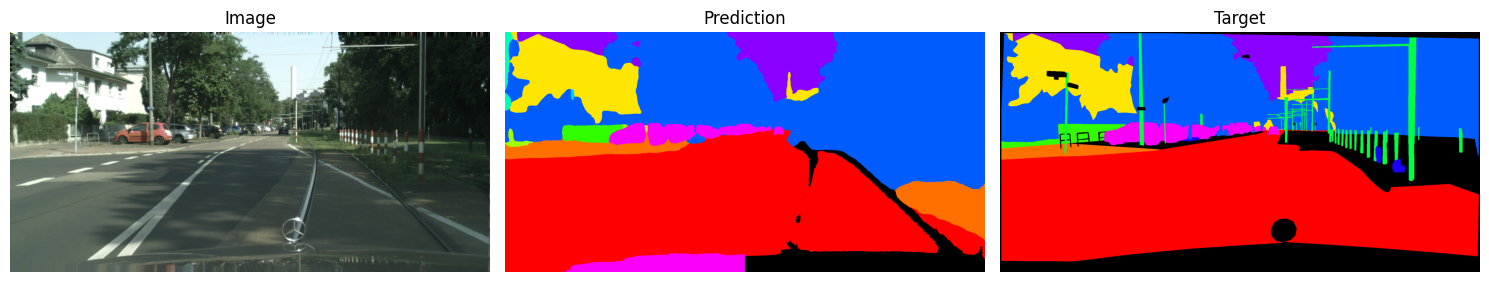

In [ ]:
# Semantic inference function.

# Input:
# - img: one image from the Cityscapes validation set
# - target: corresponding Cityscapes ground truth

# Output:
# - pred_array: predicted semantic class for each pixel
# - target_array: ground-truth semantic class for each pixe

def infer_semantic(img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model.window_imgs_semantic(imgs)  # Split the image into windows/crops for semantic inference

        #run the model on the image crops
        mask_logits_per_layer, class_logits_per_layer = model(crops)
        #mask_logits = F.interpolate( #mask_logits_per_layer[-1], data.img_size, mode="bilinear")
        mask_logits = F.interpolate(mask_logits_per_layer[-1],size=target_img_size, mode="bilinear",)

        crop_logits = model.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()

    # --- AGGIUNTA MAPPATURA ---
    # If we are using the COCO-trained model, its output labels are COCO IDs.
    # To compare them with Cityscapes ground truth, we remap them to Cityscapes IDs.
    if use_coco:
        #Start with an array filled with the ignore index.
        # Any COCO class not present in the mapping will remain ignored.
        remapped_pred = np.full(pred_array.shape, IGNORE_INDEX, dtype=np.uint8)

        # Sostituisci ogni pixel usando il tuo dizionario
        for coco_id, city_id in coco_to_cityscapes_map.items():
            remapped_pred[pred_array == coco_id] = city_id

        pred_array = remapped_pred
    # --------------------------

    target_array = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[
        0
    ].numpy()

    return pred_array, target_array


def plot_semantic_results(img, pred_array, target_array):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title("Prediction")
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data.val_dataloader().dataset[img_idx]
pred_array, target_array = infer_semantic(img, target)
plot_semantic_results(img, pred_array, target_array)

In [ ]:
import torch
import numpy as np
from torchmetrics.classification import MulticlassJaccardIndex

def calculate_dataset_miou(dataset, num_classes=19, ignore_index=255):
    # Inizializziamo metrica per calcolare la mIoU media su tutte le classi.
    miou_mean_metric = MulticlassJaccardIndex(
        num_classes=num_classes,
        average="macro"
    ).to(device)

    # Inizializziamo una seconda metrica per ottenere la IoU separata
    # per ogni singola classe Cityscapes.
    miou_class_metric = MulticlassJaccardIndex(
        num_classes=num_classes,
        average=None
    ).to(device)

    print(f"Inizio calcolo mIoU su {len(dataset)} immagini...")

    for i in range(len(dataset)):
        img, target = dataset[i]

        pred_array, target_array = infer_semantic(img, target)
        pred_array = np.asarray(pred_array)
        target_array = np.asarray(target_array)

        # Keep only pixels where BOTH prediction and target are valid Cityscapes classes.
        # Valid Cityscapes trainIds are 0, ..., 18.
        # Pixels with 255 are ignored.
        valid_mask = (
            (target_array >= 0) &
            (target_array < num_classes) &
            (pred_array >= 0) &
            (pred_array < num_classes)
        )

        if valid_mask.sum() == 0:
            print(f"Immagine {i}: nessun pixel valido, salto.")
            continue

        pred_valid = pred_array[valid_mask]
        target_valid = target_array[valid_mask]

        pred_tensor = torch.from_numpy(pred_valid).long().to(device)
        target_tensor = torch.from_numpy(target_valid).long().to(device)

        miou_mean_metric.update(pred_tensor, target_tensor)
        miou_class_metric.update(pred_tensor, target_tensor)

        if (i + 1) % 50 == 0:
            print(f"Processate {i + 1}/{len(dataset)} immagini...")

    total_miou = miou_mean_metric.compute().item()
    per_class_miou = miou_class_metric.compute().cpu().numpy()

    return total_miou, per_class_miou

# --- ESECUZIONE ---

class_names = [
    "road", "sidewalk", "building", "wall", "fence", "pole", "traffic light",
    "traffic sign", "vegetation", "terrain", "sky", "person", "rider", "car",
    "truck", "bus", "train", "motorcycle", "bicycle"
]

# Otteniamo il dataset di validazione
val_dataset = data.val_dataloader().dataset

# Avviamo il calcolo (usa 255 come ignore_index per Cityscapes)
mIoU_totale, mIoU_classi = calculate_dataset_miou(val_dataset, 19, 255)

# --- STAMPA RISULTATI ---
print("\n" + "="*45)
print(f"{'STATISTICHE DI VALUTAZIONE':^45}")
print("="*45)
print(f"{'mIoU MEDIA (Totale)':<25}: {mIoU_totale:.4f}")
print("-" * 45)

for i, val in enumerate(mIoU_classi):
    name = class_names[i] if i < len(class_names) else f"Classe {i}"
    # Se una classe non è presente, il valore sarà NaN
    if np.isnan(val):
        print(f"{name:<25}: N/A (non presente)")
    else:
        print(f"{name:<25}: {val:.4f}")
print("="*45)

Inizio calcolo mIoU su 500 immagini...
Processate 50/500 immagini...
Processate 100/500 immagini...
Processate 150/500 immagini...
Processate 200/500 immagini...
Processate 250/500 immagini...
Processate 300/500 immagini...
Processate 350/500 immagini...
Processate 400/500 immagini...
Processate 450/500 immagini...
Processate 500/500 immagini...

         STATISTICHE DI VALUTAZIONE          
mIoU MEDIA (Totale)      : 0.5231
---------------------------------------------
road                     : 0.9412
sidewalk                 : 0.6478
building                 : 0.8705
wall                     : 0.4593
fence                    : 0.4972
pole                     : 0.0000
traffic light            : 0.6061
traffic sign             : 0.0468
vegetation               : 0.8545
terrain                  : 0.0583
sky                      : 0.8972
person                   : 0.7047
rider                    : 0.0000
car                      : 0.8427
truck                    : 0.2935
bus            

# Panoptic inference (segmentation with instance IDs)

> This inference method also works when applied to a model trained for instance segmentation.

Panoptic inference assigns each pixel $[h, w]$ to the query $i$ that maximizes the product of class and mask confidence:

$$
p_i(c_i) \cdot m_i[h, w]
$$

where $c_i = \arg\max_c \, p_i(c)$ is the most likely class for query $i$. A pixel is assigned to a query only if both the class confidence and mask confidence are high. Pixels assigned to the same query form a segment labeled with $c_i$. "Stuff" segments with the same class are merged; "thing" segments are kept distinct using the query index. Low-confidence and heavily occluded predictions are filtered out.  
  
*This inference method was originally introduced in MaskFormer.*

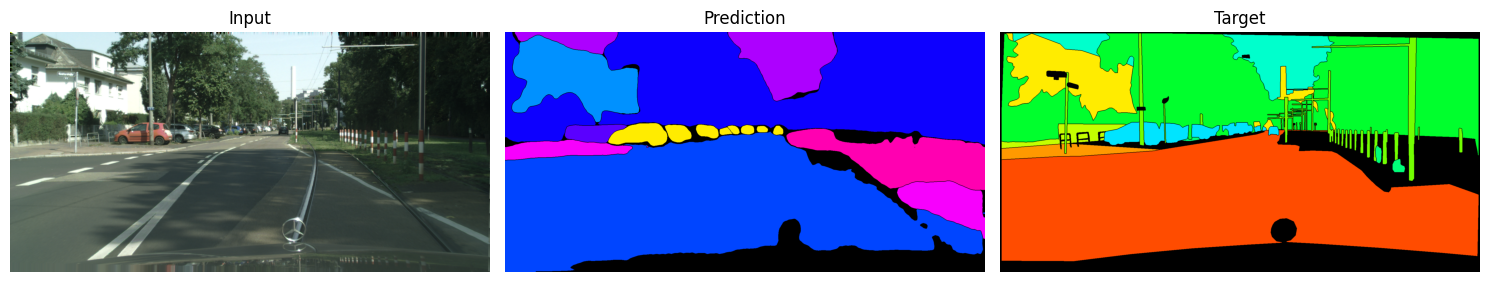

In [ ]:
def infer_panoptic(img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        transformed_imgs = model.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model(transformed_imgs)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], model.img_size, mode="bilinear"
        )
        mask_logits = model.revert_resize_and_pad_logits_instance_panoptic(
            mask_logits, img_sizes
        )

        preds = model.to_per_pixel_preds_panoptic(
            mask_logits,
            class_logits_per_layer[-1],
            model.stuff_classes,
            model.mask_thresh,
            model.overlap_thresh,
        )[0].cpu()

    pred = preds.numpy()
    sem_pred, inst_pred = pred[..., 0], pred[..., 1]

    target_seg = model.to_per_pixel_targets_panoptic([target])[0].cpu().numpy()
    sem_target, inst_target = target_seg[..., 0], target_seg[..., 1]

    return sem_pred, inst_pred, sem_target, inst_target


def draw_black_border(sem, inst, mapping):
    h, w = sem.shape
    out = np.zeros((h, w, 3))
    for s in np.unique(sem):
        out[sem == s] = mapping[s]

    combined = sem.astype(np.int64) * 100000 + inst.astype(np.int64)
    border = np.zeros((h, w), dtype=bool)
    border[1:, :] |= combined[1:, :] != combined[:-1, :]
    border[:-1, :] |= combined[1:, :] != combined[:-1, :]
    border[:, 1:] |= combined[:, 1:] != combined[:, :-1]
    border[:, :-1] |= combined[:, 1:] != combined[:, :-1]
    out[border] = 0
    return out


def plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target):
    all_ids = np.union1d(np.unique(sem_pred), np.unique(sem_target))
    mapping = {
        s: (
            [0, 0, 0]
            if s == -1 or s == model.num_classes
            else plt.cm.hsv(i / len(all_ids))[:3]
        )
        for i, s in enumerate(all_ids)
    }

    vis_pred = draw_black_border(sem_pred, inst_pred, mapping)
    vis_target = draw_black_border(sem_target, inst_target, mapping)

    img_np = (
        img.cpu().numpy().transpose(1, 2, 0) if img.dim() == 3 else img.cpu().numpy()
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Input")
    axes[1].imshow(vis_pred)
    axes[1].set_title("Prediction")
    axes[2].imshow(vis_target)
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data.val_dataloader().dataset[img_idx]
sem_pred, inst_pred, sem_target, inst_target = infer_panoptic(img, target)
plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target)